#Introduction

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.
In this business case, we use python libraries, with descriptive statistics and probabilty to dive deep into the data.

#Importing Data and Python Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749 -O final_fg.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749
To: /content/final_fg.csv
100% 7.28k/7.28k [00:00<00:00, 18.3MB/s]


#Data Exploration

In [ ]:
data = pd.read_csv('/content/final_fg.csv')
data.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
data.shape

(180, 9)

This Aerofit dataset contains 180 rows(observations) and 9 columns(features).

In [ ]:
data.dtypes

,0
Product,object
Age,int64
Gender,object
Education,int64
MaritalStatus,object
Usage,int64
Fitness,int64
Income,int64
Miles,int64


The features characteristics and its data types:
1. Product - object(string), KP281, KP481, or KP781
2. Age - int64, In years
3. Gender - object(string), either Male or Female
4. Education - int64, In years
5. MaritalStatus - object(string), Single or partnered
6. Usage - int64, average number of times its is planned to be used
7. Fitness - int64, Self-rated fitness on a 1-5 scale, 1 being poor shape and 5 being excellent.
8. Income - int64, Annual Income (in $)
9. Miles - int64, Average number of miles the customer expects to walk/run each week

In [ ]:
data['Product'] = data['Product'].astype('category')
data['Gender'] = data['Gender'].astype('category')
data['MaritalStatus'] = data['MaritalStatus'].astype('category')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


The variables Product, Gender, and MaritalStatus were converted to category datatype from object(string) for more efficient data handling and analysis because variables represent categorical groups rather than continuous numerical values.

In [ ]:
data.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


Statistical Summary Observations:
1. The median age of customer is 26 years old, while the average is 28.8 years old ranging from 18 to 50 years.
2. The average education level is about 15.6 years, while median education year is 16 years ranging from 12 to 21 years.
3. Customers plan to use the treadmill around 3 to 4 times per week, with minimum twice a week and maximum every day of the week.
4. Median fitness level and average(mean) fitness level are 3 and 3.31 respectively.
5. The median annual income of the customer is 50.5K, with it ranging from 29,562 to 104,581.
6. Customer expect to run or walk on average 103 miles per week, median distance traveeled though is 94 . Maximum distance travelled is 360 while minimum is 21 miles.


In [ ]:
data.nunique()

,0
Product,3
Age,32
Gender,2
Education,8
MaritalStatus,2
Usage,6
Fitness,5
Income,62
Miles,37


In [ ]:
data['Product'].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


In [ ]:
data['Gender'].value_counts()

,count
Gender,
Male,104
Female,76


In [ ]:
data['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,107
Single,73


From the value counts and unique value analysis, it can be observed that:
1. The dataset contains three treadmill products - KP281, KP481, KP781.
2. The KP281 model has the highest number of purchases, followed by KP481 and KP781.
3. Male customers slightly outnumber female customers, and partnered individuals are more common buyers than single individuals.
4. Several variables such as Age, Income, and Miles contain many unique values, indicating variability in customer demographics and treadmill usage patterns.

#Visual Analysis

Product Distribution

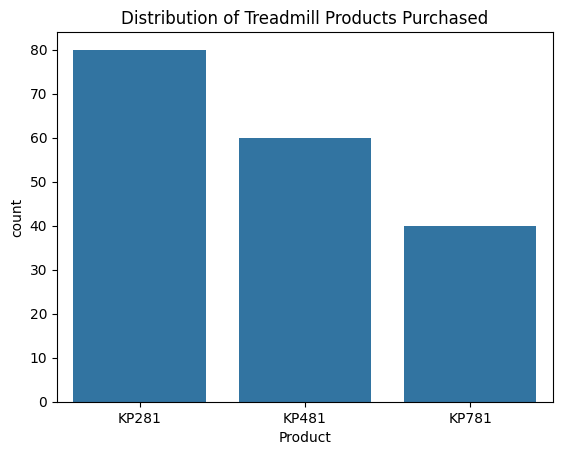

In [ ]:
sns.countplot(x='Product', data=data)
plt.title('Distribution of Treadmill Products Purchased')
plt.show()

Gender Distributions

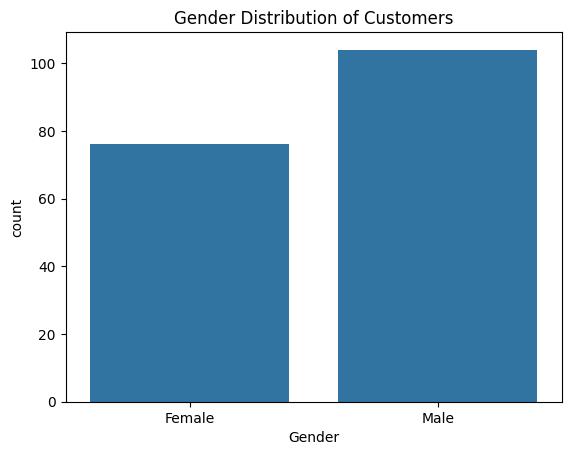

In [ ]:
sns.countplot(x='Gender', data=data)
plt.title('Gender Distribution of Customers')
plt.show()

Marital Status Distribution

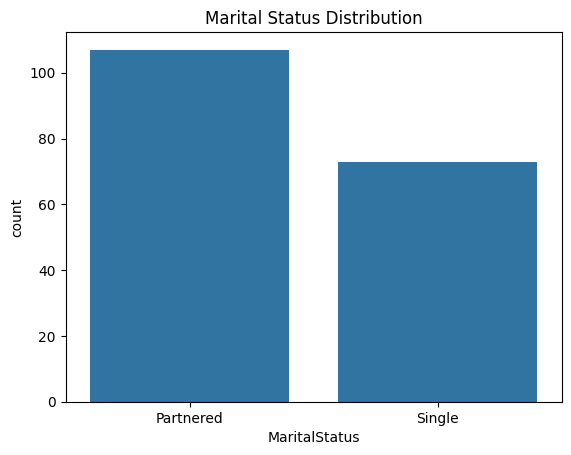

In [ ]:
sns.countplot(x='MaritalStatus', data=data)
plt.title('Marital Status Distribution')
plt.show()

Observations:
1. The KP281 treadmill appears to be the most purchased product, meaning there is higher demand for entry level model.
2. There are slightly more male customers compared to female customers among treadmill buyers.
3. Partnered individuals tends to be a larger share of treadmill customers compared to single individuals.

**Univariate Analysis**

**1. Age Distribution**

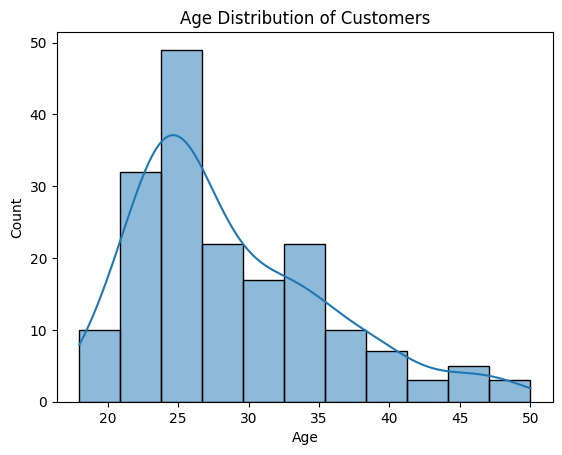

In [ ]:
sns.histplot(data['Age'], kde=True)
plt.title('Age Distribution of Customers')
plt.show()

Observation:
1. The highest number of customers fall within the age range of 20 to 30.
2. There is a drop in purchases as the age gets older.


**2. Income Distribution**

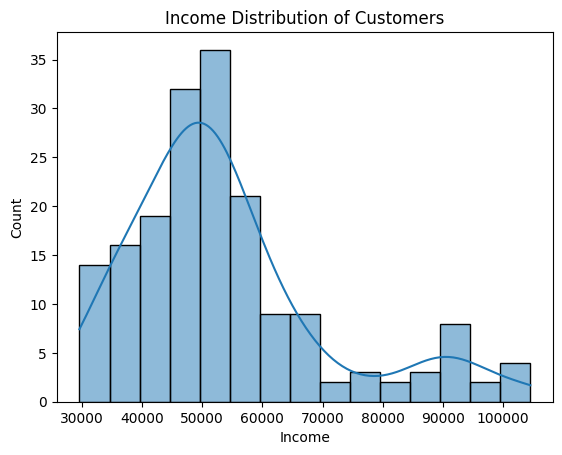

In [ ]:
sns.histplot(data['Income'], kde=True)
plt.title('Income Distribution of Customers')
plt.show()

Observations:
1. The income distribution is strongly right skewed, meaning vast majority of customers earning between 45,000 to 60,000.
2. There is a segment of customer earning above 90,000 indicating a niche premium segment.
3. The peak appearing around 50,000 to 55,000 shows that Aerofit's primary revenue comes from this particular demographic.

**3. Miles Distribution**

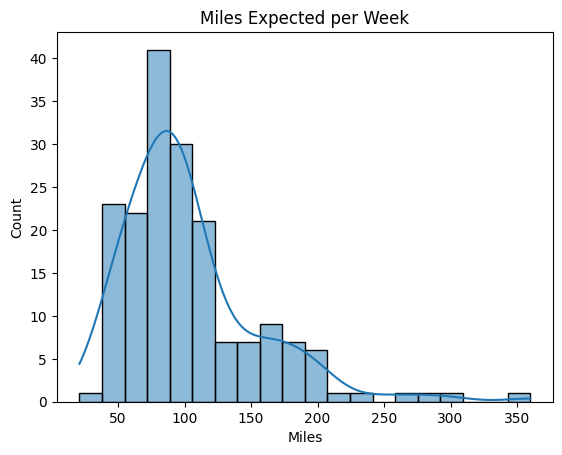

In [ ]:
sns.histplot(data['Miles'], kde=True)
plt.title('Miles Expected per Week')
plt.show()

Observations:
1. Majority of customers expect to run or walk between 50 and 125 miles per week, with significant peak around 80-100 miles range.
2. There is a clear drop after 125 miles, which means the customers are more casual/regular users, not some marathon/long distance enthusiasts.

**4. Product Distribution**

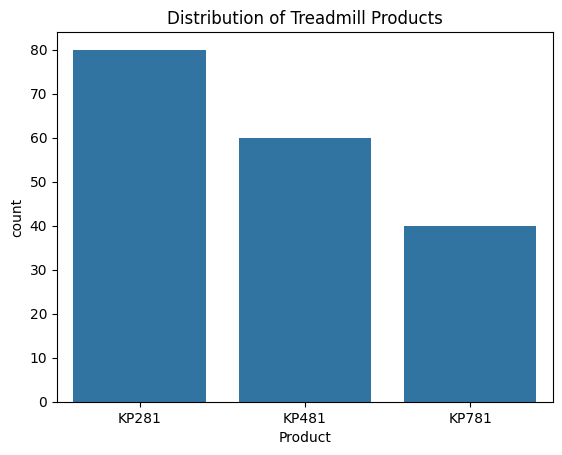

In [ ]:
sns.countplot(x='Product', data=data)
plt.title('Distribution of Treadmill Products')
plt.show()

Observations:
1. The KP281 treadmill appears to be the most purchased product, meaning there is higher demand for entry level model.
2. The customers for the entry level treadmill is almost double of the most expensive model(KP781).

**Bivariate Analysis**

**1. Product vs Gender**

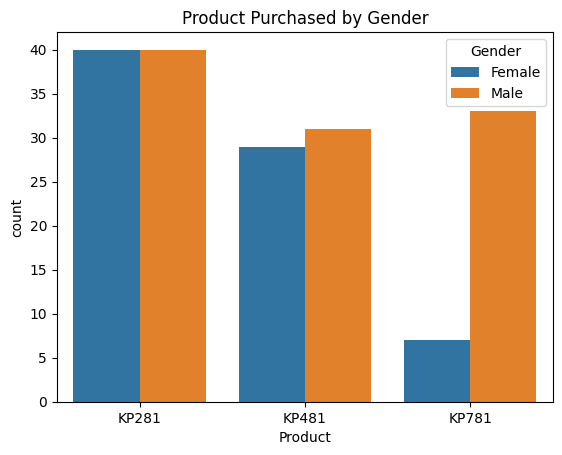

In [ ]:
sns.countplot(x='Product', hue='Gender', data=data)
plt.title('Product Purchased by Gender')
plt.show()

Observations:
1. The customer count for the entry level treadmill(KP281) is almost same for both genders.
2. For KP781, the most expensive among the three, the customer base is majority men, that too by a large margin.

**2. Product vs Income**

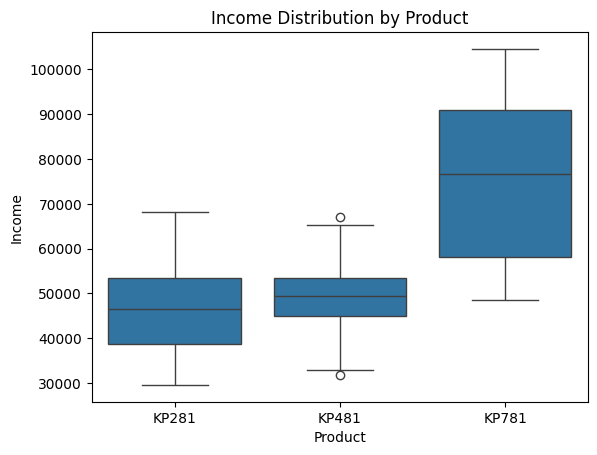

In [ ]:
sns.boxplot(x='Product', y='Income', data=data)
plt.title('Income Distribution by Product')
plt.show()

Observation:
1. There is a distinct income jump for KP781, while KP281 and KP481 have similar income distribution, the KP781 customers have higher than median income(75,000)
2. For KP281 and KP481, most customers earn between 35,000 and 55,000. The overlap between these two products is huge suggesting price isn't the only deciding factor.

**Correlation Analysis**

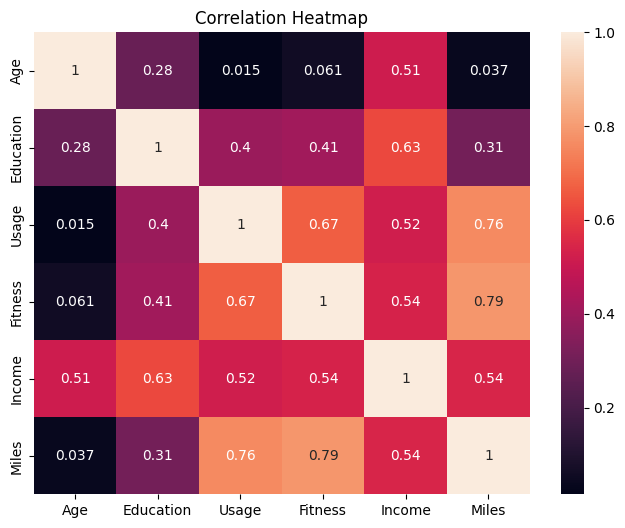

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Observations:
1. There is a strong positive correlation between, usage, fitness and miles(0.67 tp 0.79), meaning the customers who think they are fit, plan to use treadmill more often and cover more distances.
2. There is significant correlation (0.63) between education and income, meaning highly educated individuals tend to have higher income necessary for premium KP781 model.
3. Age has almost zero correlation with usage (0.015) or fitness(0.061), meaning fitness is not bound to a certain age.


**Pairplot**

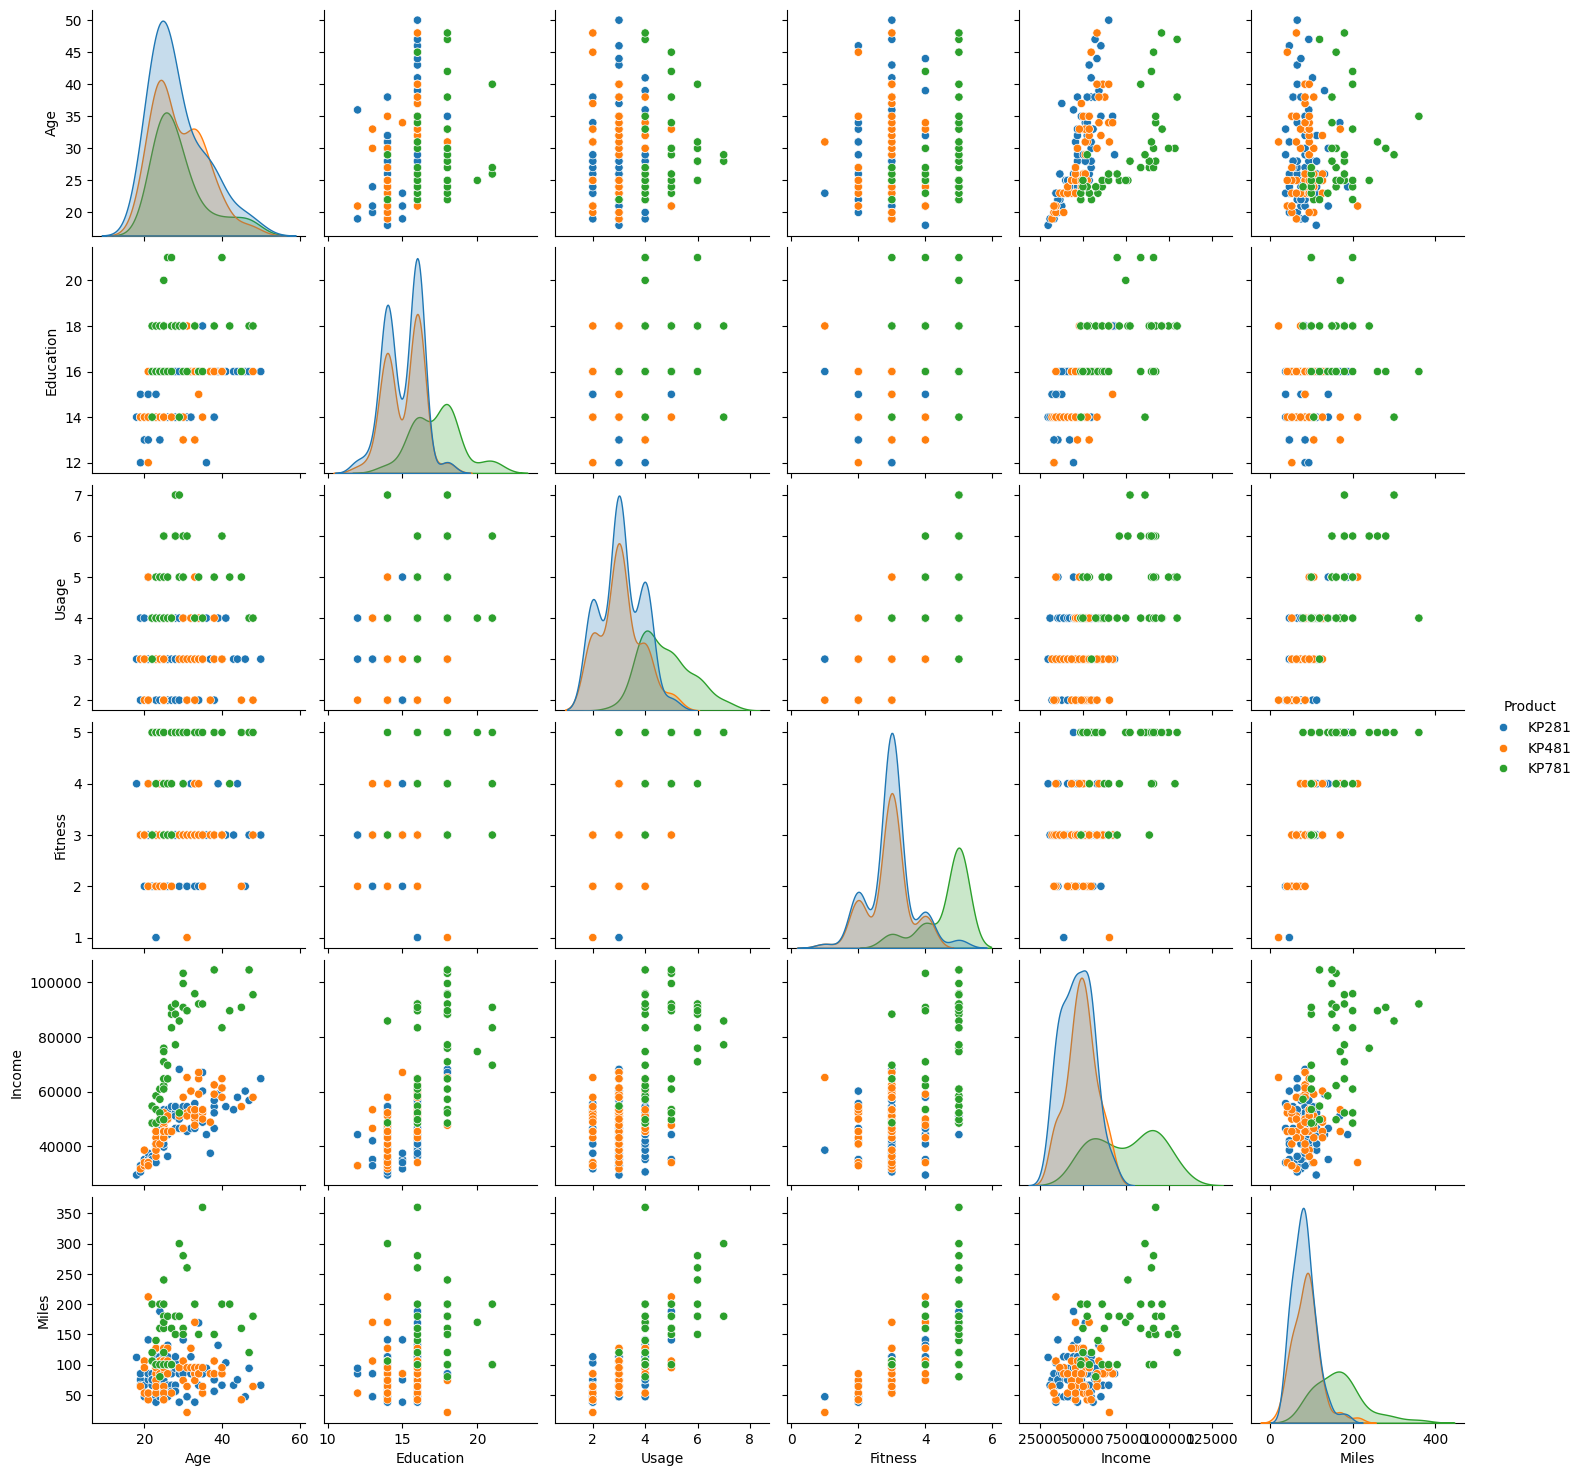

In [ ]:
sns.pairplot(data, hue='Product')
plt.show()

**Boxplot Analysis**

**1. Product vs Age**

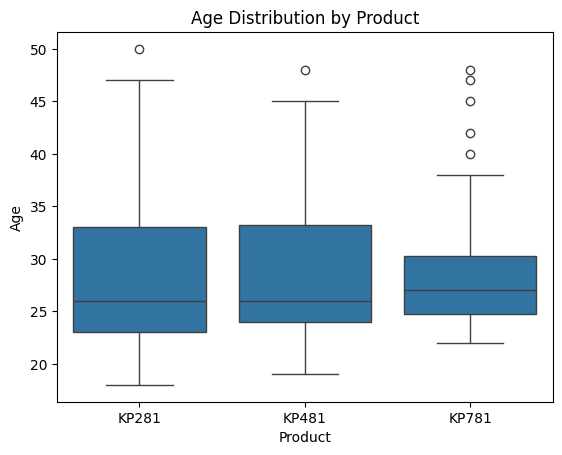

In [ ]:
sns.boxplot(x='Product', y='Age', data=data)
plt.title('Age Distribution by Product')
plt.show()

Observations:
1. The median age, suprisingly is nearly identical(around 25-26 years old) for all three products.
2. The KP281 has the tallest 'whiskers', meaning it appeals to everyone from youngest 18 years old to oldest at 50.
3. The outliers for KP781 are between age 35 and 50, showing that although typical buyer is young, there is still a niche group of older fitness enthusiasts.


**2. Product vs Income**

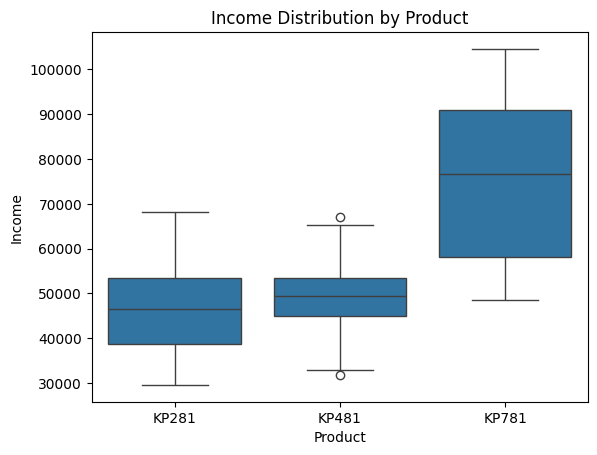

In [ ]:
sns.boxplot(x='Product', y='Income', data=data)
plt.title('Income Distribution by Product')
plt.show()

Observations:
1. There is a stark contrast between the customer base for KP781 and other two models. The KP781 is a premium product, with a median income roughly 75,000 that is nearly double that of entry level models.
2. Income profiles for the KP281 and KP481 are remarkably similar, with both having median in 45 to 50K range, suggesting that the choice between these two models are not all about income  but their specific fitness needs.


**3. Product vs Miles**

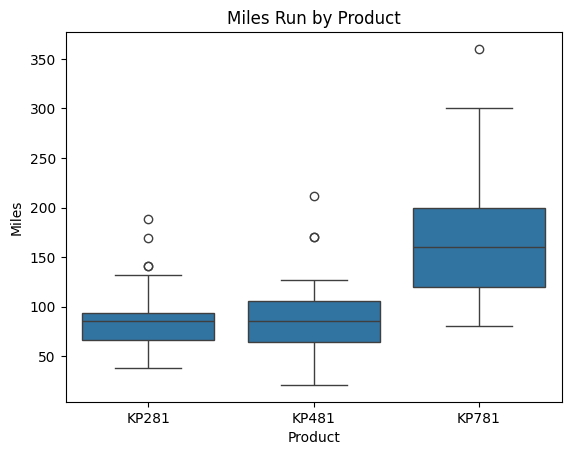

In [ ]:
sns.boxplot(x='Product', y='Miles', data=data)
plt.title('Miles Run by Product')
plt.show()

Observations:
1. The premium KP781 is clearly the choice for high intensity runners, highlighting the need for marketing that emphasizes durability and professional grade quality.
2. KP281 and KP481 have nearly same miles being run, indicating these are bought by casual walkers/runners.

**Pairplot**

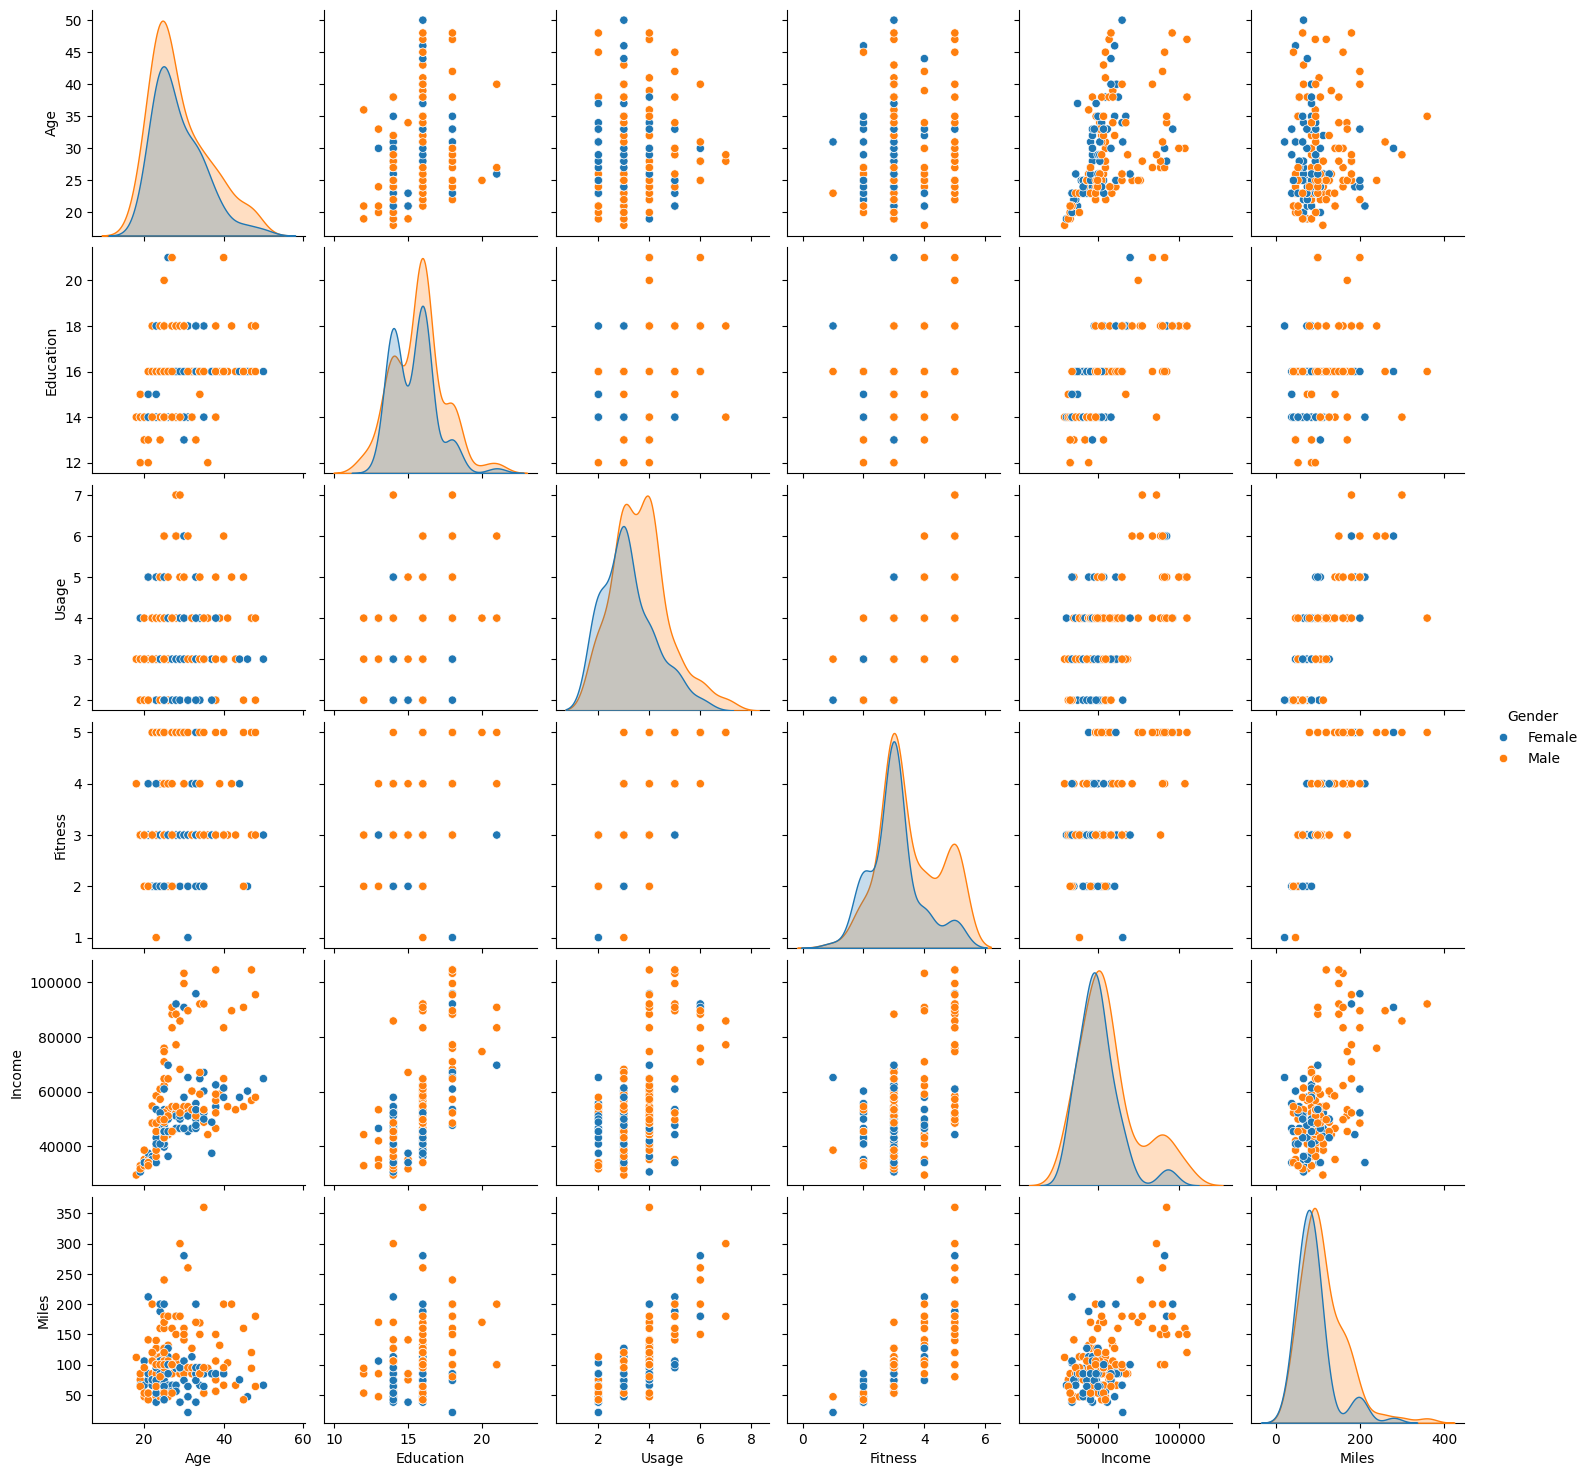

In [ ]:
sns.pairplot(data, hue='Gender')
plt.show()

**Missing Value Check**

In [ ]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


The missing value check shows that all columns contain 0 missing values. This means the dataset is complete and no data cleaning is required .

**Outlier Detection**

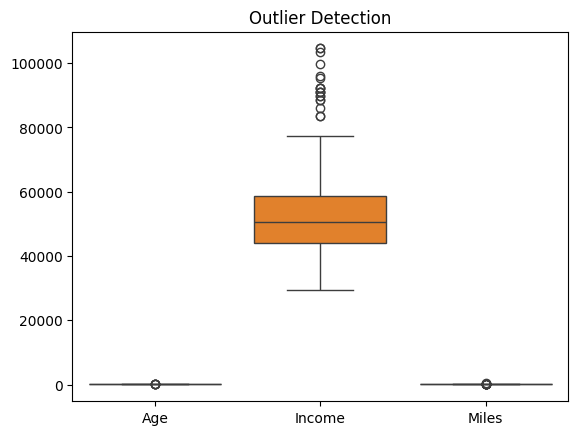

In [ ]:
sns.boxplot(data=data[['Age','Income','Miles']])
plt.title('Outlier Detection')
plt.show()

The boxplot indicates the presence of several outliers in the Income variable, where some customers have significantly higher incomes compared to the rest of the dataset. Age and Miles do not show strong outlier patterns relative to the overall distribution. These outliers may represent customers with higher purchasing power or heavier treadmill usage.

#Probability Analysis and Contingency Tables

**Marginal Probability of Product Purchase**

In [ ]:
pd.crosstab(data['Product'], columns='Count')

col_0,Count
Product,
KP281,80
KP481,60
KP781,40


In [ ]:
pd.crosstab(data['Product'], columns='Count', normalize=True)

col_0,Count
Product,
KP281,0.444444
KP481,0.333333
KP781,0.222222


Observation:
1. The KP281 treadmill has the highest probability of purchase (44.4%), followed by KP481 (33.3%) and KP781 (22.2%).
2. The entry-level treadmill (KP281) is the most popular among customers, while the advanced treadmill (KP781) has the lowest purchase probability, likely due to its higher price.

**Product vs Gender (Conditional Probability)**

In [ ]:
pd.crosstab(data['Gender'], data['Product'])

Product,KP281,KP481,KP781
Gender,,,
Female,40,29,7
Male,40,31,33


In [ ]:
pd.crosstab(data['Gender'], data['Product'], normalize='index')

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


Observation:
1. Among female customers, the highest probability of purchase is for KP281 (52.6%), followed by KP481 (38.2%), while KP781 has the lowest probability (9.2%)
2. Among male customers, the probabilities are more evenly distributed, but KP781 has a higher purchase probability (31.7%) compared to females.
3. This suggests that male customers are more likely to purchase the advanced treadmill model, while female customers tend to prefer entry-level models.

**Product vs Marital Status**

In [ ]:
pd.crosstab(data['MaritalStatus'], data['Product'])

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,48,36,23
Single,32,24,17


In [ ]:
pd.crosstab(data['MaritalStatus'], data['Product'], normalize='index')

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


Observation:
1. For both groups, KP281 has the highest probability of purchase, followed by KP481 and KP781.
2. The probabilities are very close between partnered and single individuals, suggesting that marital status does not significantly influence the choice of treadmill model, though partnered customers represent a slightly larger share of overall buyers.

#Conclusion

**Business Insights**

1. There is a stronger demand for entry level KP281 treadmill as it was the most purchased product of the three.
2. Male customers slightly outnumber female customers among treadmill buyers.
3. Partnered customers represent a large share of buyers compared to single customers.
4. Average age of customer is around 29 years, with majority of them falling between 20 to 35 age bracket.
5. Average education level of around 15-16 years shows many buyers likely have college level education.
6. On average, the treadmill is planned to be used around 3 to 4 times per week.
7. Average self-rated fitness level is around 3, indicating moderate fitness among most customers.
8. Average income of a customer annualy is around 53K, with income ranging from about 29K to 104K.
9. Average run or walk for a customer is around 103 miles per week.
10. Customers who purchased KP781 have higher income levels and higher fitness ratings, which means this particular model appeals to more serious fitness enthusiasts.

**Customer Profiling - Categorization of Users**

**1. KP281 (Entry Level Model)**
- It is the most popular treadmill, accounting for 44% of the purchase.
- Its customers generally belong to middle income segment.
- Users typically plan to use the treadmill around 3 times per week.
- The average fitness level of KP281 buyers is around 3, indicating moderate fitness.
- Both male and female customers purchase this model in similar proportions.
- KP281 attracts younger customers and beginners in fitness routines.

**2. KP481 (Mid Range Model)**
- KP481 accounts for around 33% of purchases.
- Buyers typically have moderate income levels similar to KP281 buyers.
- Customers generally plan to use the treadmill about 3 times per week.
- The average fitness level of KP481 buyers is also around 3.
- KP481 attracts customers looking for a balance between price and performance.

**3. KP781 (Premium Model)**
- KP781 accounts for about 22% of total purchases, making it the least purchased models.
- Customers buying KP781 generally have higher income levels.
- These users plan to use the treadmill more frequently (around 4 times per week).
- The average fitness level of KP781 buyers is higher, typically around 4.
- KP781 is more popular among male customers and more serious runners.

**Recommendations**

1. Aerofit should focus marketing of KP281 toward beginners and budget-conscious customers.
2. The company should position KP481 as a balanced mid-range option for moderately active users.
3. KP781 should be marketed as a premium treadmill targeting high-income and serious fitness enthusiasts.
4. Promotional campaigns encouraging regular exercise habits and treadmill usage could increase demand.
5. Aerofit can provide personalized product recommendations based on customer income, fitness level, and expected treadmill usage.